In [310]:
import numpy as np
import matplotlib.pyplot as plt

In [311]:
class MonteCarlo():
    def __init__(self, size=1000000, min=0, max=1):
        self.size = size
        self.min = min
        self.max = max
        self.D = None
        self.sample_x = None
        self.sample_y = None

    def sampler(self):
        self.sample_x = np.random.uniform(self.min, self.max, self.size)
        self.sample_y = np.random.uniform(self.min, self.max, self.size)

In [312]:
class MonteCarloSquare(MonteCarlo):
    def __init__(self, x_min=0, x_max=1, y_min=0, y_max=1, size=1000000):
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max
        super().__init__(size=size)

    def indicatorFunction(self):
        self.D = []
        for x, y in zip(self.sample_x, self.sample_y):
            if (self.x_min < x < self.x_max) & (self.y_min < y < self.y_max):
                self.D.append(1)
            else:
                self.D.append(0)

    def occupiedArea(self):
        self.sampler()
        self.indicatorFunction()
        P = sum(self.D) / len(self.D)
        return P

In [313]:
class MonteCarloCircle(MonteCarlo):

    def indicatorFunction(self):
        self.D = []
        for x, y in zip(self.sample_x, self.sample_y):
            if (x**2 + y**2 < 1):
                self.D.append(1)
            else:
                self.D.append(0)

    def occupiedArea(self):
        self.sampler()
        self.indicatorFunction()
        P = sum(self.D) / len(self.D)
        return P

In [314]:
square = MonteCarloSquare(x_min=0, x_max=0.2, y_min=0, y_max=0.2)
square2 = MonteCarloSquare(x_min=0, x_max=0.2, y_min=0.8, y_max=1)

print(square.occupiedArea())
print(square2.occupiedArea())

0.040127
0.040132


In [315]:
circ = MonteCarloCircle()
A = circ.occupiedArea()
print(A, A*4)

0.785114 3.140456


In [316]:
Ns = np.linspace(1, 10000, 100).astype(int)

Ps = []
Ps2 = []
for N in Ns:
    square = MonteCarloSquare(size=N, x_min=0, x_max=0.2, y_min=0, y_max=0.2)
    square2 = MonteCarloSquare(size=N, x_min=0, x_max=0.2, y_min=0.8, y_max=1)
    Ps.append(square.occupiedArea())
    Ps2.append(square2.occupiedArea())

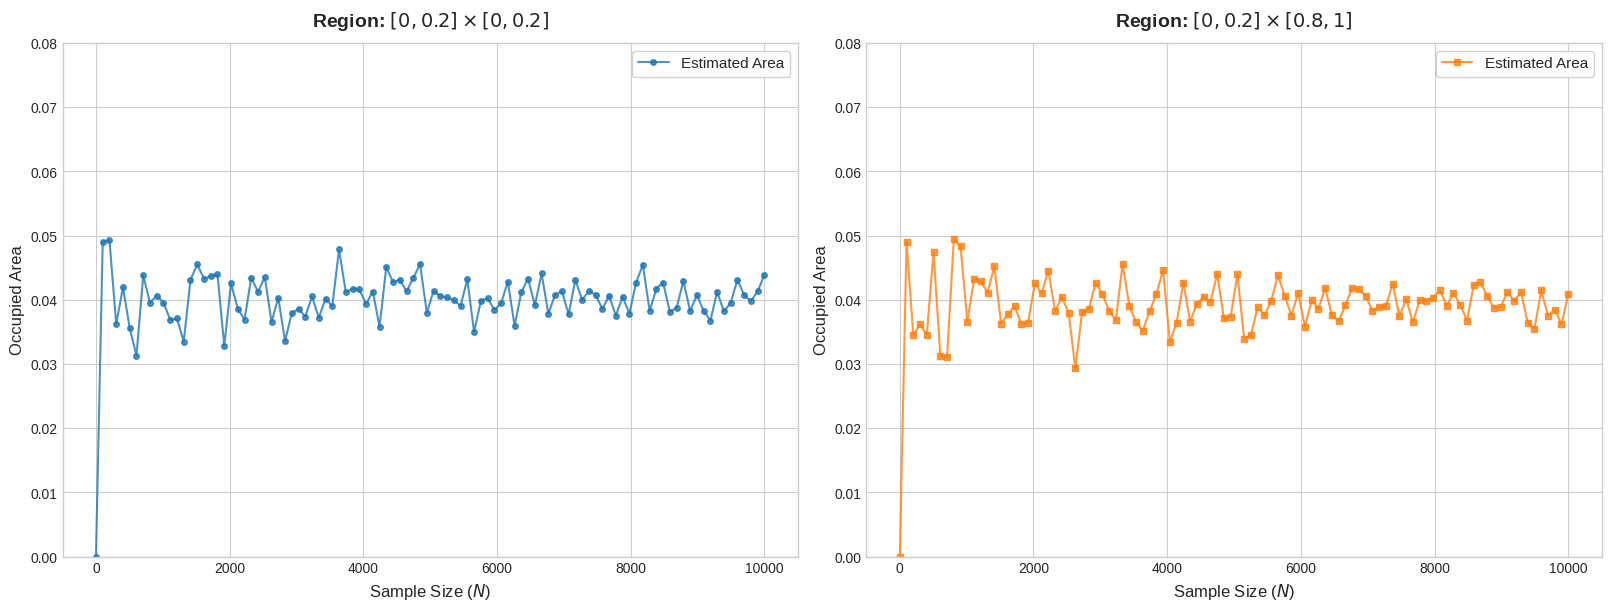

In [317]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# --- Plot 1: Region [0, 0.2] x [0, 0.2] ---
axes[0].plot(Ns, Ps, color='#1f77b4', marker='o', markersize=4, alpha=0.8, 
             linestyle='-', linewidth=1.5, label='Estimated Area')
axes[0].set_title('Region: $[0, 0.2] \\times [0, 0.2]$', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Sample Size ($N$)', fontsize=12)
axes[0].set_ylabel('Occupied Area', fontsize=12)
axes[0].tick_params(labelsize=10)
axes[0].legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

# --- Plot 2: Region [0, 0.2] x [0.8, 1] ---
axes[1].plot(Ns, Ps2, color='#ff7f0e', marker='s', markersize=4, alpha=0.8, 
             linestyle='-', linewidth=1.5, label='Estimated Area')
axes[1].set_title('Region: $[0, 0.2] \\times [0.8, 1]$', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Sample Size ($N$)', fontsize=12)
axes[1].set_ylabel('Occupied Area', fontsize=12)
axes[1].tick_params(labelsize=10)
axes[1].legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

# Set Y limits explicitly for both plots (adjust min/max as needed)
axes[0].set_ylim(0, 0.08)
axes[1].set_ylim(0, 0.08)

plt.show()

In [318]:
class MonteCarloStraightLine(MonteCarloSquare):
    def __init__(self, a=1, b=0.5, size=10000):
        self.a = a
        self.b = b
        self.xs = []
        self.ys = []
        super().__init__(size=size)

    def indicatorFunction(self):
        self.D = []
        self.xs = []
        self.ys = []
        for x, y in zip(self.sample_x, self.sample_y):
            if (self.x_min < x < self.x_max) & (self.y_min < y < self.b - self.a*x):
                self.D.append(1)
                self.xs.append(x)
                self.ys.append(y)
            else:
                self.D.append(0)

        return self.xs, self.ys

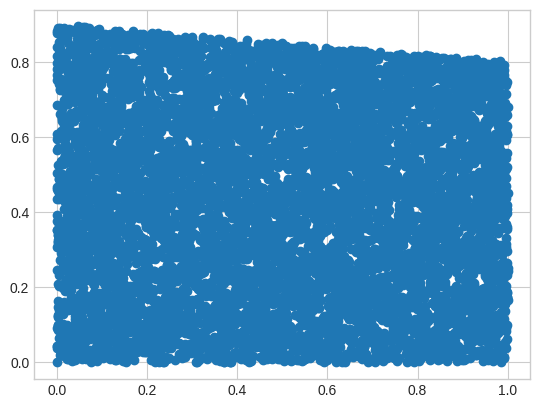

In [325]:
line = MonteCarloStraightLine(size=10000, a=.1, b=.9)
line.sampler()
x, y = line.indicatorFunction()
plt.scatter(x,y)

In [320]:
line.occupiedArea()

0.453